# AI/ML Bootcamp Lecture 5

## MNIST Handwritten digit classifier continued
For this in-class exercise we will look at the MNIST handwritten digit dataset and do some denoising!

### Imports and style

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
height = 5
plt.rcParams["figure.figsize"] = [1.618*height, height]

### Load the MNIST data into a NumPy arrays

In [ ]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

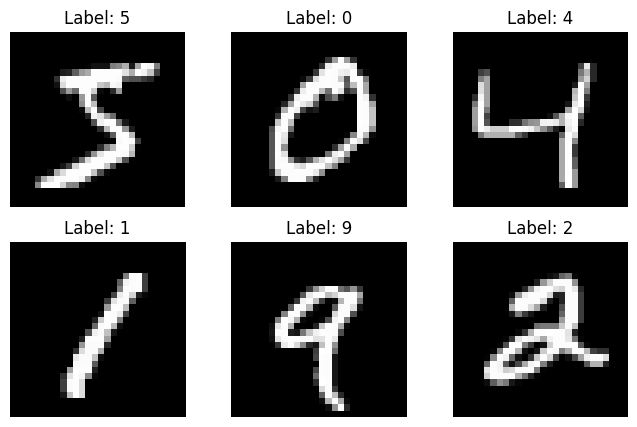

In [ ]:
# Plot 6 images from the training set
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

In [ ]:
# Let's add some noise
clean_images = train_images.astype("float32") / 255.0
clean_images = clean_images[..., None]
clean_test_images = test_images.astype("float32") / 255.0
clean_test_images = clean_test_images[..., None]

noise_sigma = 0.3
noisy_images = clean_images + noise_sigma * np.random.normal(size=clean_images.shape)
noisy_images = np.clip(noisy_images, 0, 1)
noisy_test_images = clean_test_images + noise_sigma * np.random.normal(size=clean_test_images.shape)
noisy_test_images = noisy_test_images[..., None]

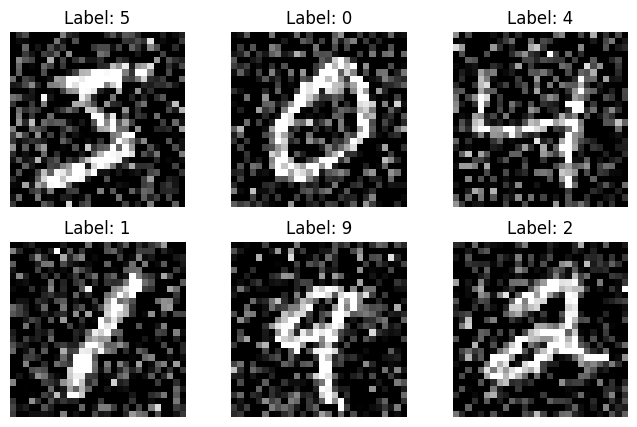

In [ ]:
# Plot 6 images from the noisy training set
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(noisy_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

In [ ]:
# let's build a denoising autoencoder
denoiser = keras.Sequential()
denoiser.add(layers.Input(shape=(28, 28, 1)))
denoiser.add(layers.Conv2D(32, 3, padding="same", activation="relu"))
denoiser.add(layers.Conv2D(32, 3, padding="same", activation="relu"))
denoiser.add(layers.Conv2D(1, 3, padding="same", activation="linear"))

denoiser.compile(optimizer=keras.optimizers.Adam(1e-3),loss="mse")

history = denoiser.fit(
    noisy_images,
    clean_images,
    validation_split=.2,
    epochs=10,
    batch_size=128
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0095 - val_loss: 0.0062
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0058 - val_loss: 0.0055
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0053 - val_loss: 0.0052
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0051 - val_loss: 0.0051
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0050 - val_loss: 0.0050
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0050 - val_loss: 0.0050
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 9/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 10/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0049 - val_loss: 0.0049


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


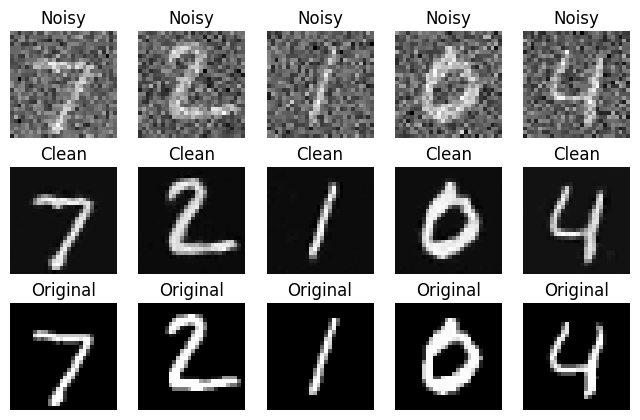

In [ ]:
# Let's see if it worked and take 5 noisy input images and see if it removes the noise
cleaned_test_images = denoiser.predict(noisy_test_images[:5])

# Plot the images side by side noisy vs clean
plt.figure(figsize=(8,5))
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(noisy_test_images[i].squeeze(), cmap='gray')
    plt.title(f"Noisy")
    plt.axis('off')
    plt.subplot(3, 5, i + 6)
    plt.imshow(cleaned_test_images[i].squeeze(), cmap='gray')
    plt.title(f"Clean")
    plt.axis('off')
    plt.subplot(3, 5, i + 11)
    plt.imshow(clean_test_images[i].squeeze(), cmap='gray')
    plt.title(f"Original")
    plt.axis('off')

In [ ]:
# Get accuracy
test_loss = denoiser.evaluate(np.squeeze(noisy_test_images, axis=-1), clean_test_images)
print(f"Test loss: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0056
Test loss: 0.005580883007496595


In [ ]:
# Regression example. Let's take the MNIST data and create a regression for the total ink used
total_ink = np.sum(train_images, axis=(1, 2))
total_ink_test = np.sum(test_images, axis=(1, 2))


In [ ]:
total_ink

array([27525, 31095, 19443, ..., 22132, 20428, 20920], dtype=uint64)

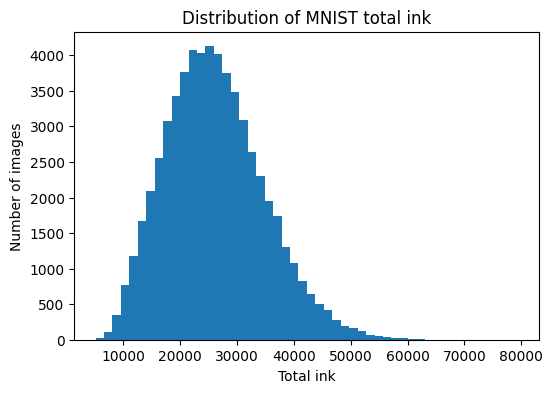

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(total_ink, bins=50)
plt.xlabel("Total ink")
plt.ylabel("Number of images")
plt.title("Distribution of MNIST total ink")
plt.show()

In [ ]:
model = keras.Sequential()
model.add(layers.Input(shape=(28, 28, 1)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(32, activation="relu"))
model.add(layers.Dense(1, activation="linear"))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,353 (204.50 KB)

 Trainable params: 52,353 (204.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_images,total_ink, epochs=10, batch_size=128, validation_split=.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 78124656.0000 - mae: 3557.0403 - val_loss: 21977.9824 - val_mae: 113.1975
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 14475.0225 - mae: 91.4778 - val_loss: 9568.5518 - val_mae: 75.9978
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6994.5444 - mae: 64.8550 - val_loss: 5480.6094 - val_mae: 58.0459
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4307.1963 - mae: 51.3940 - val_loss: 3668.4163 - val_mae: 47.7517
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3015.7136 - mae: 43.1176 - val_loss: 2664.8206 - val_mae: 40.7676
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2244.6216 - mae: 37.3003 - val_loss: 2007.3540 - val_mae: 35.4194
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1725.7223 - mae: 32.7552 - val_loss: 1608.5015 - val_mae: 31.7710
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1345.0885 - mae: 28.9159 - val_loss: 1222.5752 - 

In [ ]:
# Evaluate the model
test_loss, test_mae = model.evaluate(test_images, total_ink_test)
print(f"Test loss: {test_loss}")
print(f"Test MAE: {test_mae}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 711.7751 - mae: 21.1077
Test loss: 711.7750854492188
Test MAE: 21.10770606994629


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


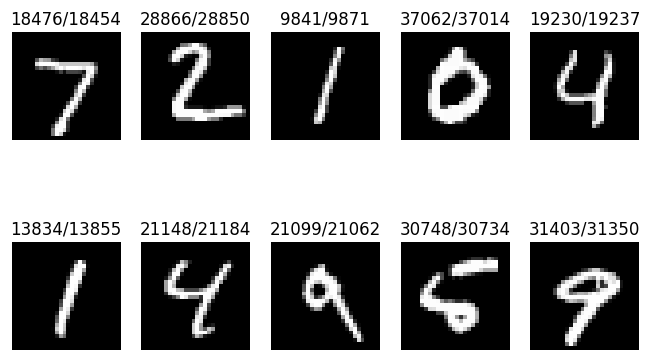

In [ ]:
# Show the first ten images with total ink prediction and actual total ink in the title
predictions = model.predict(test_images[:10])
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i], cmap='gray')
    plt.title(f"{predictions[i][0]:.0f}/{total_ink_test[i]:.0f}")
    plt.axis('off')